# Imports

In [5]:
!pip install vaderSentiment
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.1 MB/s eta 0:00:00


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from spacy import displacy
from spacy import tokenizer
import spacy
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import TfidfModel, LsiModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [9]:
# set plot options
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_color = '#00bfbf'

# Loading Dataset

In [11]:
data = pd.read_csv('133 - fake-news-data.csv')

In [12]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 1.0, 'Count of Article Classification')

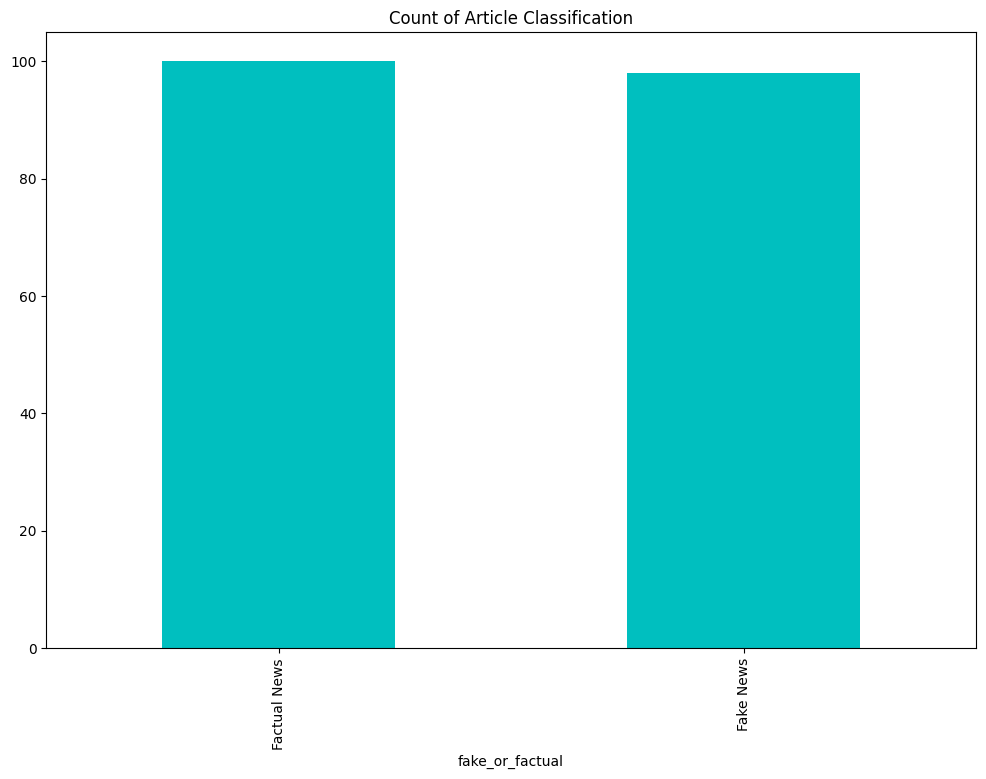

In [14]:
data['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_color)
plt.title('Count of Article Classification')

# POS Tagging

In [18]:
nlp = spacy.load('en_core_web_sm')

In [20]:
fake_news = data[data['fake_or_factual'] == 'Fake News']
fact_news = data[data['fake_or_factual'] == 'Factual News']

In [21]:
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydocs = list(nlp.pipe(fact_news['text']))

In [22]:
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [23]:
fake_tagsdf = []
columns = ['token', 'ner_tag', 'pos_tag']

In [24]:
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)

In [25]:
fake_tagsdf = pd.concat(fake_tagsdf)

In [26]:
fact_tagsdf = []

for ix, doc in enumerate(fact_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)

In [27]:
fact_tagsdf = pd.concat(fact_tagsdf)

In [28]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [29]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='count').sort_values('count', ascending=False)
pos_counts_fake.head(10)

,token,pos_tag,count
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [30]:
pos_counts_fact = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='count').sort_values('count', ascending=False)
pos_counts_fact.head(10)

,token,pos_tag,count
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [31]:
pos_counts_fake.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

,token
pos_tag,
NOUN,2586
VERB,1817
PROPN,1672
ADJ,882
ADV,413
NUM,221
PRON,96
ADP,89
AUX,62


In [32]:
pos_counts_fact.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

,token
pos_tag,
NOUN,2179
VERB,1539
PROPN,1379
ADJ,747
ADV,263
NUM,205
PRON,79
ADP,70
AUX,43


In [33]:
pos_counts_fake[pos_counts_fake.pos_tag == 'NOUN'][:15]

,token,pos_tag,count
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
8011,year,NOUN,44
3138,campaign,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [34]:
pos_counts_fact[pos_counts_fact.pos_tag == 'NOUN'][:15]

,token,pos_tag,count
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
2497,campaign,NOUN,42


# Named Entities

In [35]:
top_entities_fake = fake_tagsdf[fake_tagsdf.ner_tag != ''].groupby(['token', 'ner_tag']).size().reset_index(name='count').sort_values('count', ascending=False)

In [36]:
top_entities_fact = fact_tagsdf[fact_tagsdf.ner_tag != ''].groupby(['token', 'ner_tag']).size().reset_index(name='count').sort_values('count', ascending=False)

In [42]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'PERSON': sns.color_palette("Set2").as_hex()[2],
    'NORP': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6],
}

[Text(0.5, 1.0, 'Most Common Named Entities in Fake News')]

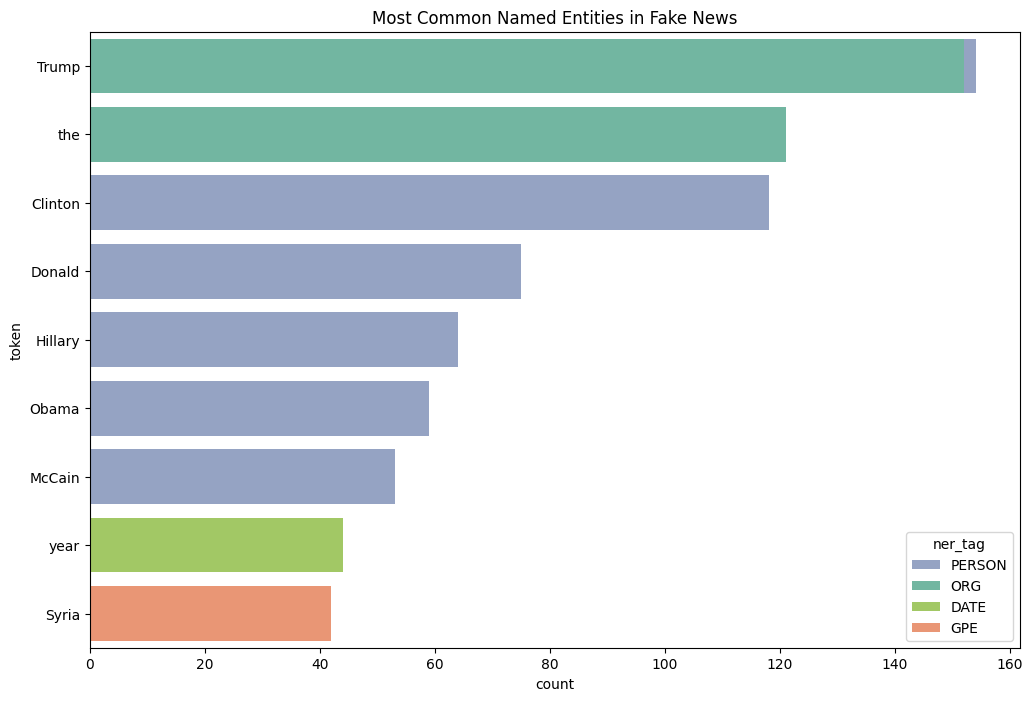

In [44]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[:10],
    orient = 'h',
    dodge = False
).set(title='Most Common Named Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Named Entities in Factual News')]

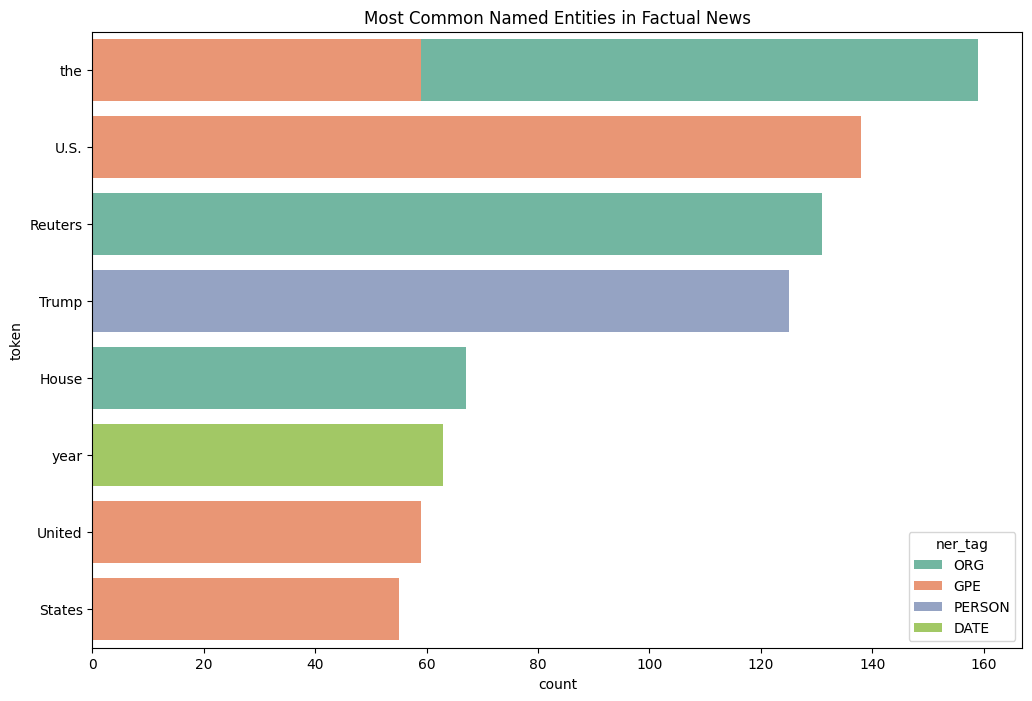

In [46]:
sns.barplot(
    x = 'count',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[:10],
    orient = 'h',
    dodge = False
).set(title='Most Common Named Entities in Factual News')

# Text Pre-Processing

In [47]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [50]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s", "", x['text']), axis=1)

In [51]:
data['text_clean'] = data['text_clean'].str.lower()

In [52]:
data['text_clean'] = data.apply(lambda x: re.sub(r"[^\w\s]", "", x['text_clean']), axis=1)

In [54]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [55]:
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [56]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [59]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [60]:
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis=1)

In [62]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [63]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [64]:
tokens_clean = sum(data['text_clean'], [])

In [69]:
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0       (trump,)    580
1        (said,)    580
2           (u,)    277
3       (state,)    275
4   (president,)    259
5       (would,)    226
6         (one,)    160
7     (clinton,)    141
8        (year,)    139
9  (republican,)    137


/tmp/ipykernel_9376/2597118424.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#00bfbf'` for the same effect.

  sns.barplot(


[Text(0.5, 1.0, 'Most Common Unigrams After Processing')]

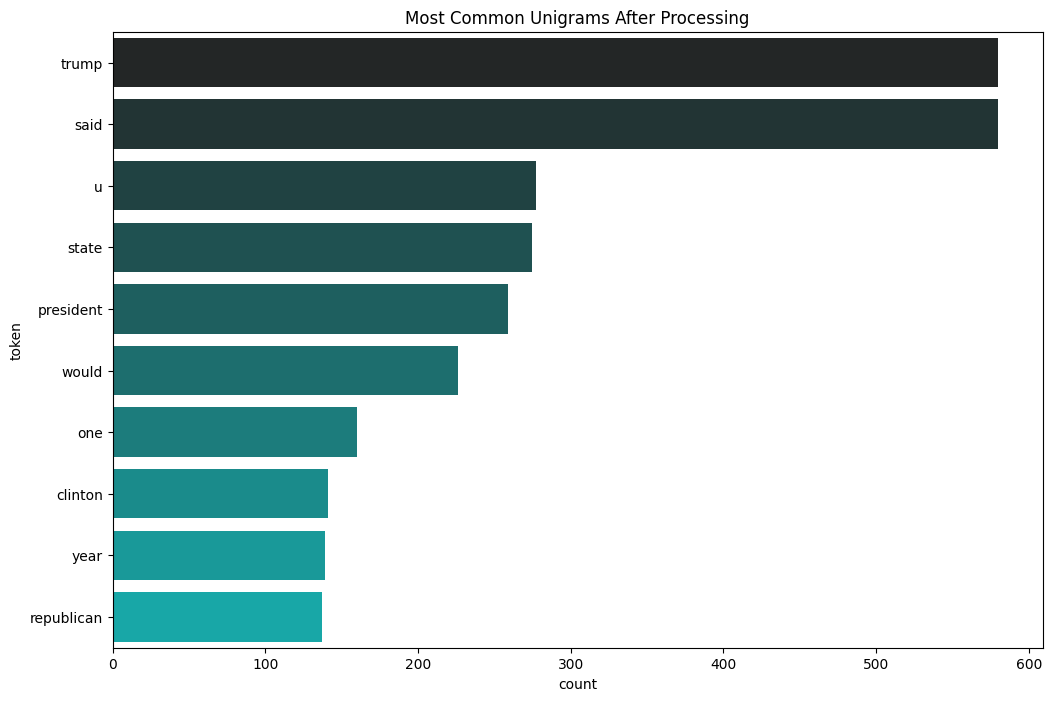

In [74]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(
    x="count",
    y="token",
    data=unigrams,
    orient="h",
    color=default_plot_color,
    hue="token",
    legend=False
).set(title='Most Common Unigrams After Processing')

In [75]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()).reset_index()[:10]
print(bigrams)

                     index  count
0          (donald, trump)    113
1          (united, state)     84
2           (white, house)     74
3      (president, donald)     47
4       (hillary, clinton)     39
5              (new, york)     33
6         (supreme, court)     30
7             (image, via)     29
8         (official, said)     26
9  (trump, administration)     26


/tmp/ipykernel_9376/990502039.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#00bfbf'` for the same effect.

  sns.barplot(


[Text(0.5, 1.0, 'Most Common Bigrams After Processing')]

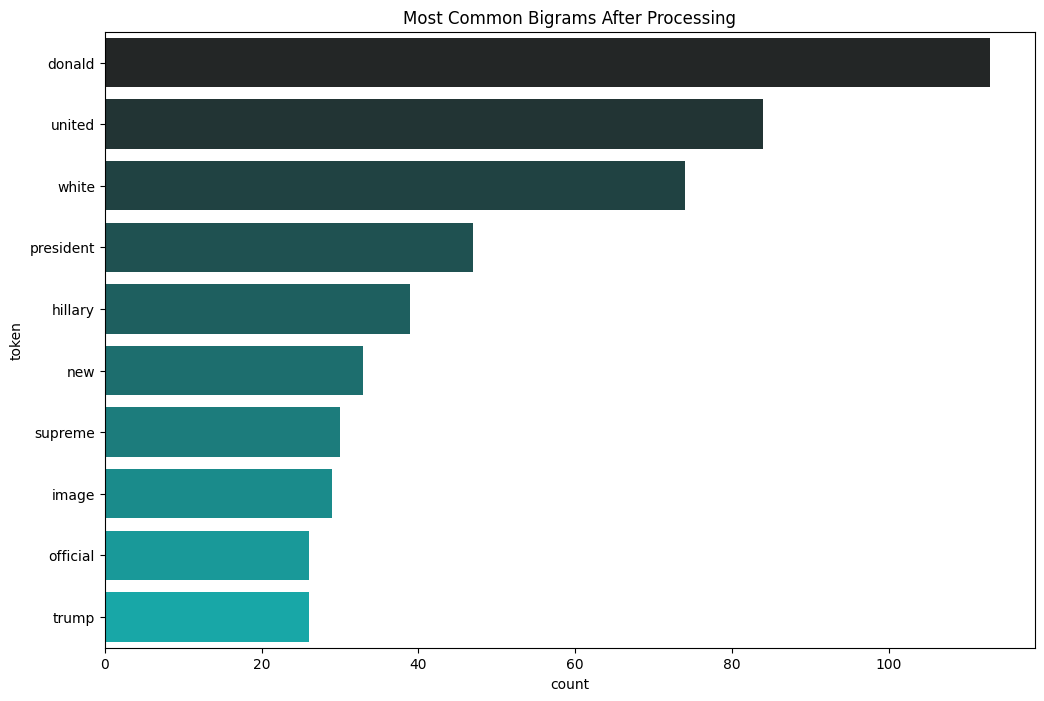

In [76]:
bigrams['token'] = bigrams['index'].apply(lambda x: x[0])

sns.barplot(
    x="count",
    y="token",
    data=bigrams,
    orient="h",
    color=default_plot_color,
    hue="token",
    legend=False
).set(title='Most Common Bigrams After Processing')

# Sentiment Analysis

In [77]:
vader_sentiment = SentimentIntensityAnalyzer()

In [78]:
data['vader_sentiment_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [79]:
bins = [-1, -0.1, 0.1, 1]
names = ['Negative', 'Neutral', 'Positive']
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins=bins, labels=names)

In [80]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive


<Axes: xlabel='vader_sentiment_label'>

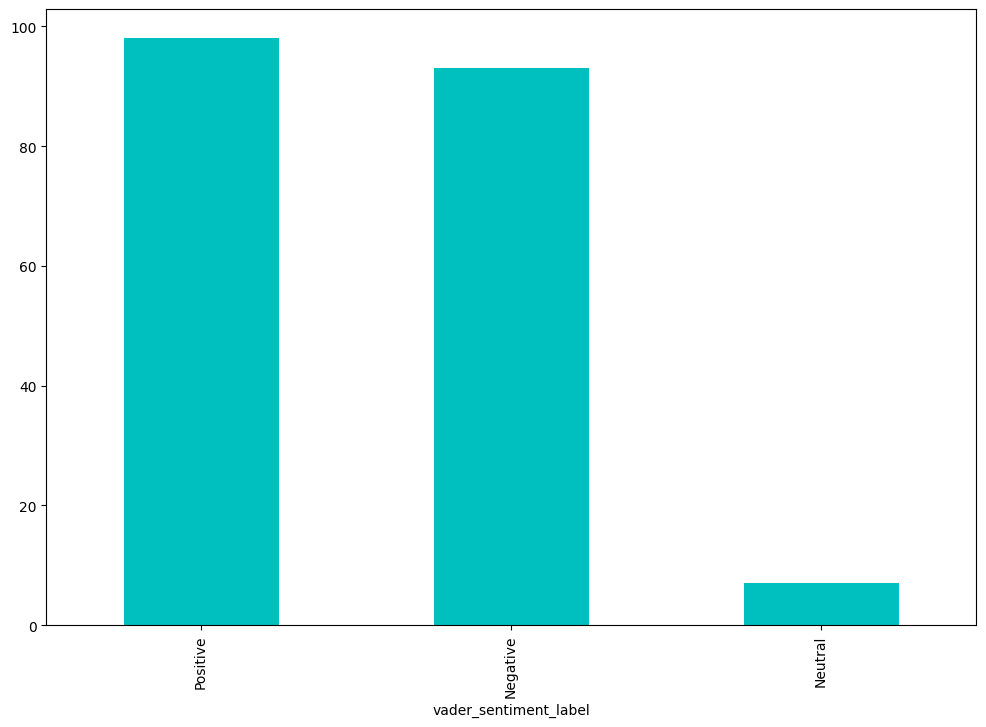

In [81]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_color)

/tmp/ipykernel_9376/1118385706.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

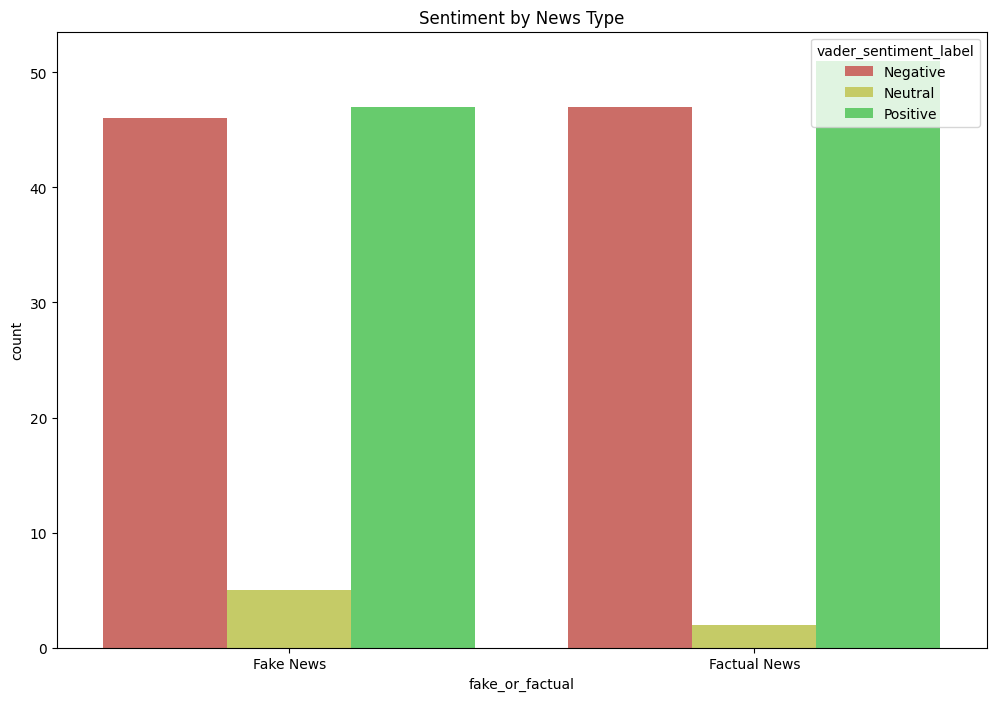

In [83]:
from seaborn.palettes import color_palette
sns.countplot(
    x='fake_or_factual',
    hue='vader_sentiment_label',
    data=data,
    palette=sns.color_palette("hls")
).set(title='Sentiment by News Type')

# Topic Modelling

In [84]:
fake_news_text = data[data['fake_or_factual'] == 'Fake News']['text_clean'].reset_index(drop=True)

In [85]:
dictionary_fake = corpora.Dictionary(fake_news_text)

In [87]:
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

In [88]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(
        corpus=doc_term_fake,
        id2word=dictionary_fake,
        num_topics=num_topics_i,
    )
    model_list.append(model)
    coherencemodel = CoherenceModel(
        model=model,
        texts=fake_news_text,
        dictionary=dictionary_fake,
        coherence='c_v'
    )
    coherence_values.append(coherencemodel.get_coherence())

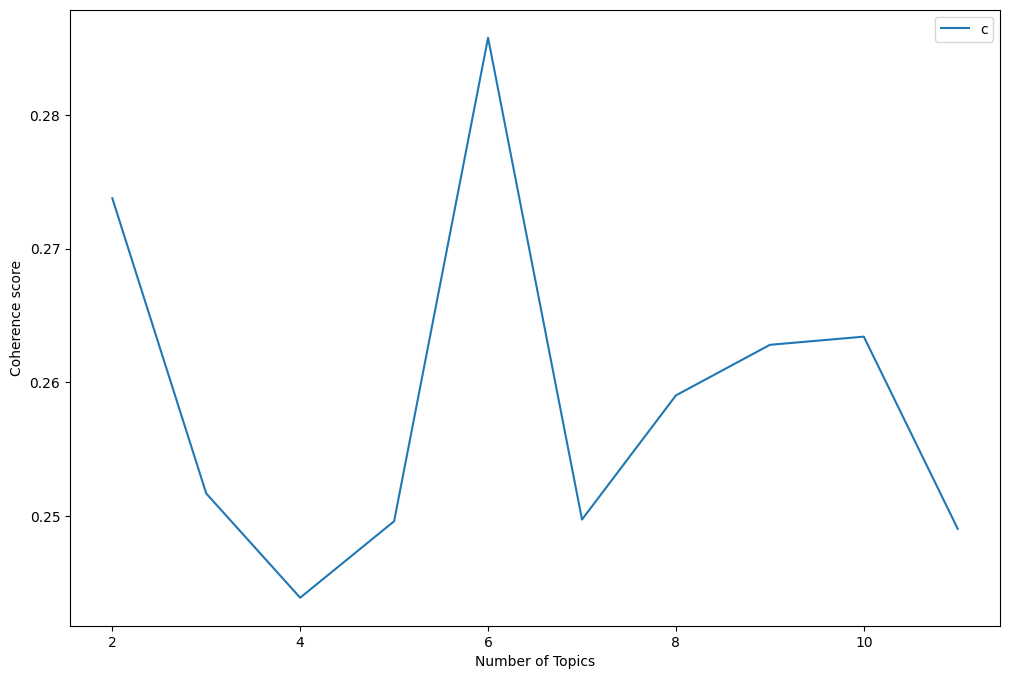

In [89]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [90]:
num_topics_lda = 7
lda_model = gensim.models.LdaModel(
    corpus=doc_term_fake,
    id2word=dictionary_fake,
    num_topics=num_topics_lda
)

In [92]:
lda_model.print_topics(num_topics=num_topics_lda, num_words=10)

[(0,
  '0.009*"trump" + 0.004*"u" + 0.004*"time" + 0.004*"donald" + 0.004*"said" + 0.004*"would" + 0.004*"obama" + 0.003*"told" + 0.003*"one" + 0.003*"know"'),
 (1,
  '0.010*"trump" + 0.005*"clinton" + 0.005*"state" + 0.005*"said" + 0.004*"president" + 0.004*"mccain" + 0.004*"one" + 0.004*"would" + 0.003*"donald" + 0.003*"u"'),
 (2,
  '0.012*"trump" + 0.006*"president" + 0.005*"said" + 0.004*"u" + 0.004*"would" + 0.004*"american" + 0.004*"year" + 0.004*"one" + 0.004*"time" + 0.003*"clinton"'),
 (3,
  '0.020*"trump" + 0.006*"state" + 0.006*"said" + 0.005*"clinton" + 0.005*"president" + 0.005*"republican" + 0.004*"would" + 0.004*"time" + 0.004*"woman" + 0.004*"donald"'),
 (4,
  '0.010*"trump" + 0.004*"email" + 0.004*"student" + 0.004*"u" + 0.004*"clinton" + 0.004*"state" + 0.003*"woman" + 0.003*"said" + 0.003*"record" + 0.003*"one"'),
 (5,
  '0.006*"president" + 0.005*"trump" + 0.004*"obama" + 0.004*"clinton" + 0.003*"one" + 0.003*"would" + 0.003*"state" + 0.003*"said" + 0.003*"republica

In [93]:
def tfidf_corpus(doc_term_matrix):
  tfidf = TfidfModel(doc_term_matrix, normalize=True)
  corpus_tfidf = tfidf[doc_term_matrix]
  return corpus_tfidf

In [105]:
'''
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
  coherence_values = []
  model_list = []

  for num_topics_i in range(min_topics, max_topics+1):
    model = LsiModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics_i
    )
    model_list.append(model)
    coherencemodel = CoherenceModel(
        model=model,
        texts=text,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_values.append(coherencemodel.get_coherence())

    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()
    '''
def get_coherence_scores(corpus, dictionary, texts, min_topics, max_topics):
  coherence_values = []
  model_list = []

  for num_topics in range(min_topics, max_topics + 1):
      # 1. Treina o modelo (exemplo com LDA)
      model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics)
      model_list.append(model)

      # 2. Calcula a coerência
      coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')

      coherence_values.append(coherencemodel.get_coherence())

  # 4. O gráfico (Onde o erro acontece se os tamanhos forem diferentes)
  x = range(min_topics, max_topics + 1)
  plt.plot(x, coherence_values)
  plt.xlabel("Num Topics")
  plt.ylabel("Coherence score")
  plt.show()

  return model_list, coherence_values

In [106]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)

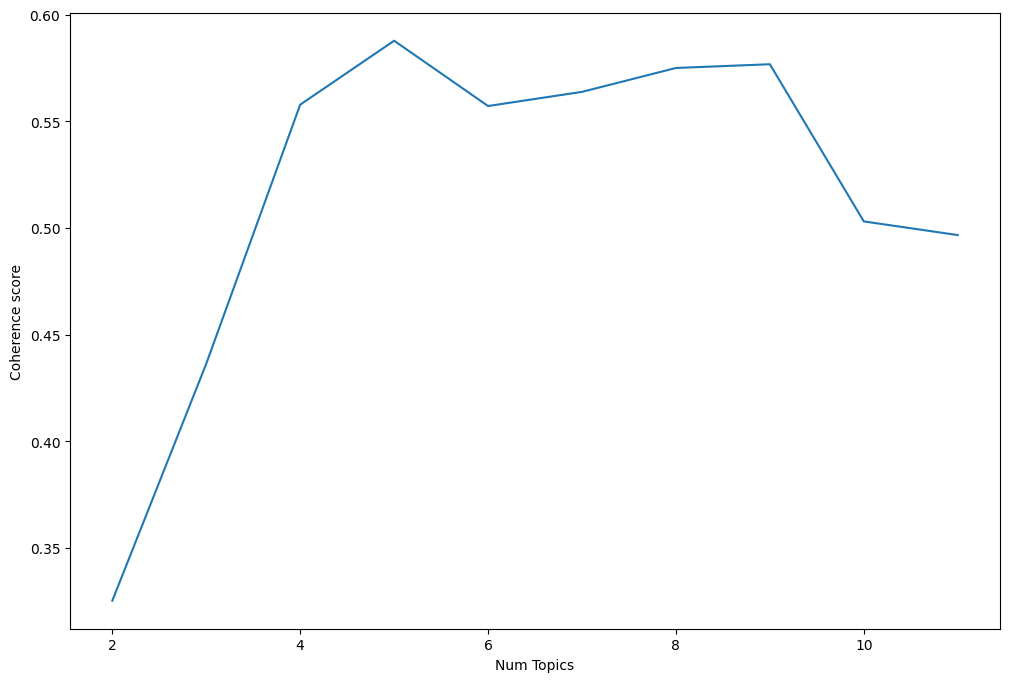

([<gensim.models.ldamodel.LdaModel at 0x7d24ea63d010>,
 [np.float64(0.3252564090792178),
  np.float64(0.43634763708199137),
  np.float64(0.5577880669874076),
  np.float64(0.5877681609345572),
  np.float64(0.5571572333520763),
  np.float64(0.5637955947404539),
  np.float64(0.5749929383281016),
  np.float64(0.5767443434307695),
  np.float64(0.5030688492845903),
  np.float64(0.496666430889463)])

In [107]:
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [108]:
lsa_model = LsiModel(
    corpus=corpus_tfidf_fake,
    id2word=dictionary_fake,
    num_topics=num_topics_lda
)

In [109]:
lsa_model.print_topics()

[(0,
  '0.190*"trump" + 0.136*"clinton" + 0.095*"hillary" + 0.094*"obama" + 0.089*"president" + 0.087*"woman" + 0.078*"republican" + 0.077*"party" + 0.077*"flynn" + 0.074*"candidate"'),
 (1,
  '-0.325*"boiler" + -0.284*"acr" + -0.244*"room" + -0.240*"pm" + -0.186*"broadcast" + -0.180*"radio" + -0.142*"tune" + -0.142*"animal" + -0.134*"jay" + -0.132*"episode"'),
 (2,
  '-0.623*"flynn" + -0.182*"immunity" + -0.122*"nana" + -0.116*"mr" + -0.110*"30" + -0.108*"march" + -0.102*"russian" + -0.100*"source" + 0.095*"school" + -0.092*"adviser"'),
 (3,
  '0.217*"clinton" + -0.186*"school" + -0.176*"student" + 0.141*"hillary" + -0.121*"county" + -0.121*"flynn" + 0.110*"sander" + 0.098*"debate" + 0.097*"woman" + 0.091*"nominee"'),
 (4,
  '0.200*"email" + -0.194*"trump" + 0.168*"dnc" + -0.142*"flynn" + 0.126*"clinton" + -0.112*"cruz" + 0.111*"department" + 0.110*"rich" + 0.102*"wikileaks" + 0.099*"sander"'),
 (5,
  '-0.276*"student" + -0.160*"conference" + -0.160*"school" + -0.137*"trump" + 0.125*"

# Creating our classification model

In [110]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive


In [112]:
X = [','.join(map(str, l)) for l in data['text_clean']]

In [113]:
Y = data['fake_or_factual']

In [114]:
countvec = CountVectorizer()

In [115]:
countvec_fit = countvec.fit_transform(X)

In [116]:
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=countvec.get_feature_names_out())

In [123]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size=0.3)

In [124]:
lr = LogisticRegression(random_state=0).fit(X_train, y_train)

In [125]:
y_pred_lr = lr.predict(X_test)

In [126]:
accuracy_score(y_pred_lr, y_test)

0.8833333333333333

In [127]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

Factual News       0.91      0.88      0.90        34
   Fake News       0.85      0.88      0.87        26

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [128]:
svm = SGDClassifier().fit(X_train, y_train)

In [129]:
y_pred_svm = svm.predict(X_test)

In [130]:
accuracy_score(y_pred_svm, y_test)

0.85

In [132]:
print(classification_report(y_pred_svm, y_test))

              precision    recall  f1-score   support

Factual News       0.85      0.88      0.87        33
   Fake News       0.85      0.81      0.83        27

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

